In [1]:
import pandas as pd
import matplotlib.pyplot as plt

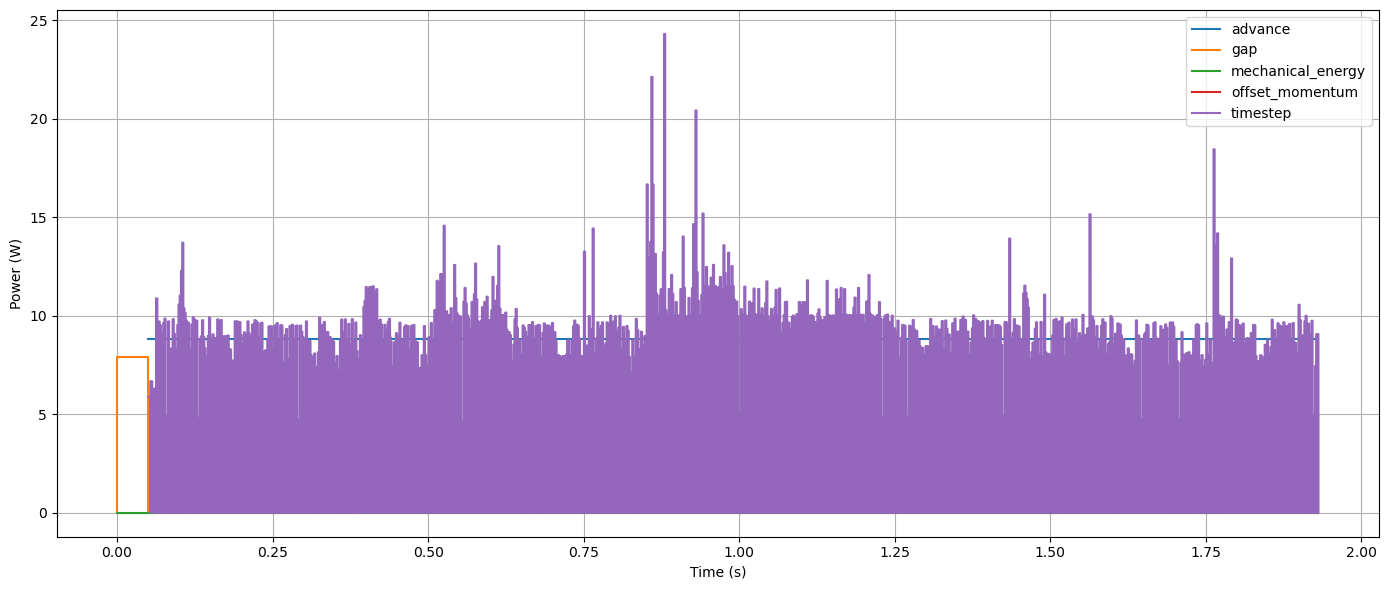

In [2]:
df = pd.read_csv('../target/nbody.csv')
df['power_w'] = df['energy_uj'] / df['duration_ns'] * 1000.0

fig, ax = plt.subplots(figsize=(14, 6))

for region, group in df.groupby('region'):
    events = []

    for _, row in group.iterrows():
        start = row['start_ns'] * 1e-9
        end = (row['start_ns'] + row['duration_ns']) * 1e-9
        power = row['power_w']
        events.append((start, power))
        # TODO: whether this is `0` or `power` depends on whether there is a gap to the next measurement.
        events.append((end, 0.0))

    times = [t for t, _ in events]
    powers = [p for _, p in events]

    ax.step(
        times,
        powers,
        where='post',
        label=region,
        linewidth=1.5,
    )

ax.set_xlabel('Time (s)')
ax.set_ylabel('Power (W)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

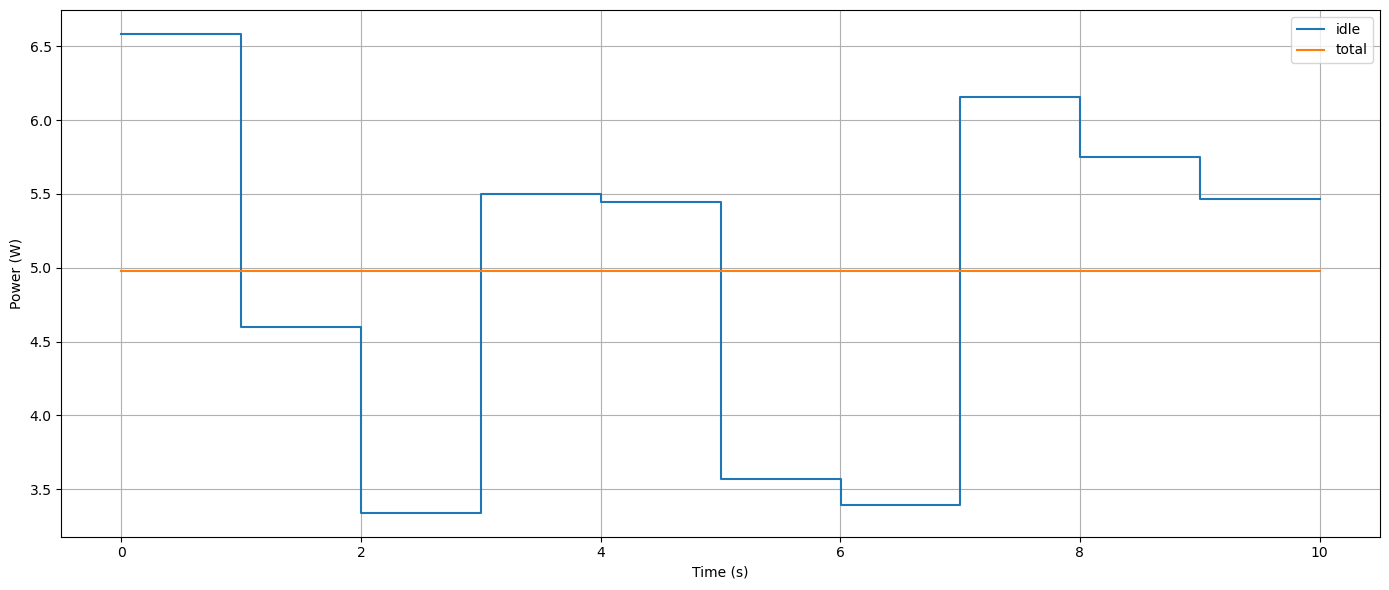

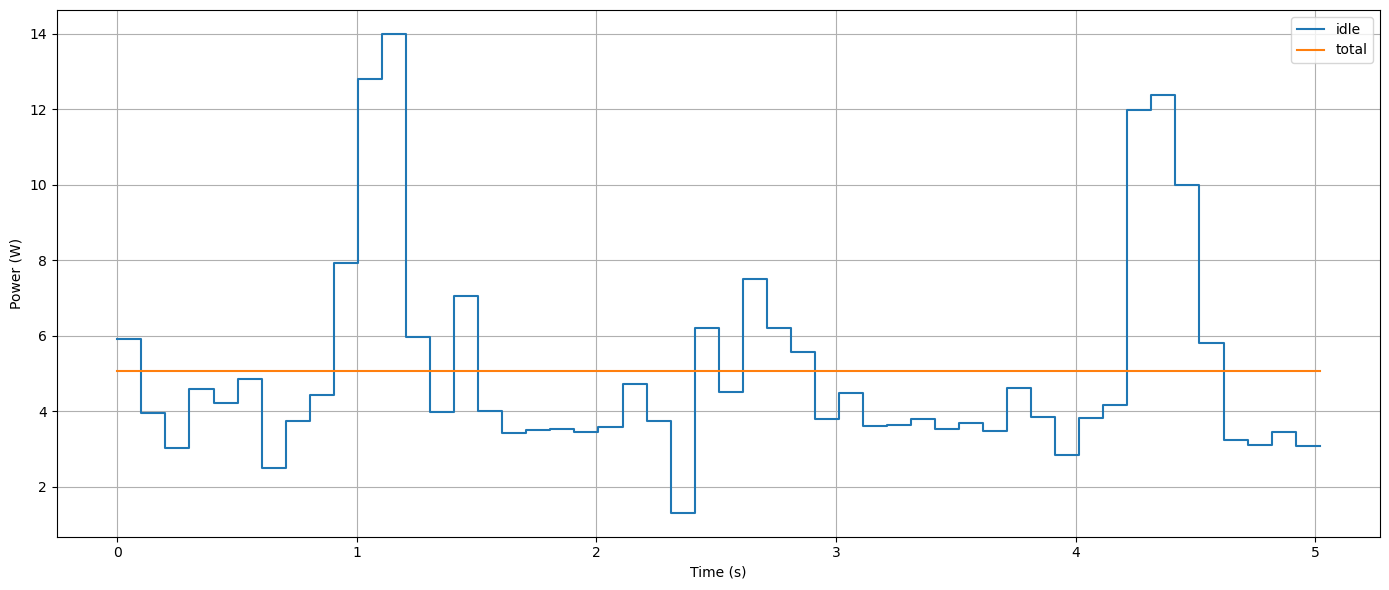

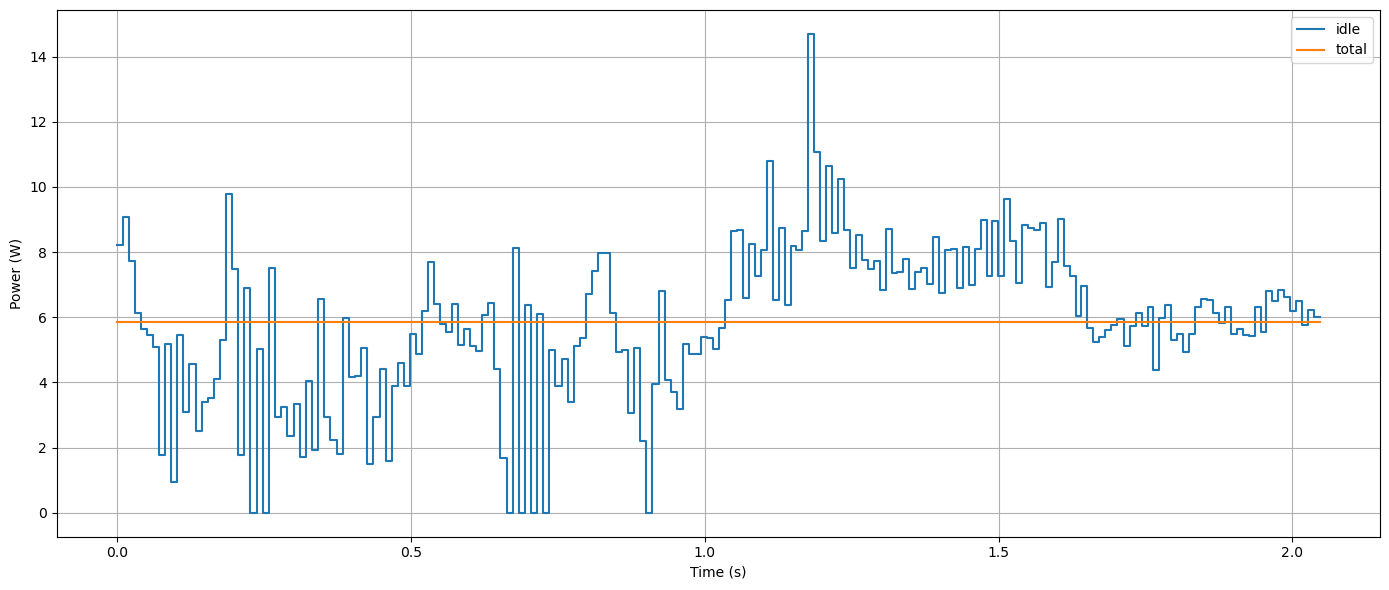

In [28]:
for hz in [1, 10, 100]:
    df = pd.read_csv(f'../target/idle_{hz}.csv')
    df = df[~df['region'].str.startswith('gap_')]
    df['power_w'] = df['energy_uj'] / df['duration_ns'] * 1000.0

    fig, ax = plt.subplots(figsize=(14, 6))

    for region, group in df.groupby('region'):
        xs, ys = [], []

        for _, row in group.iterrows():
            start = row['start_ns'] * 1e-9
            end = (row['start_ns'] + row['duration_ns']) * 1e-9
            power = row['power_w']
            xs.append(start)
            xs.append(end)
            ys.append(power)
            ys.append(power)

        ax.step(xs, ys, where='post', label=region)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power (W)')
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()